# 03 — Neuroevolution (NSGA-II) — Continuous Actions

This notebook evolves neural prescriptors that output **target land-use fractions**
per cell. This matches the Project Resilience / ESP approach.

## How it works

1. Each prescriptor is a small neural network (features → 16 tanh → softmax → 4 outputs)
2. Outputs are target fractions: [forest, wetland, agriculture, grassland]
3. The simulator scores the **transition** from current to target land use
4. NSGA-II evolves the population toward Pareto-optimal trade-offs
5. Seed prescriptors (RHEA) initialize the population with known-good strategies

## Objectives (all minimized internally)

- Maximize biodiversity gain
- Maximize carbon gain
- Minimize cost (including budget penalty if change > 25%)
- Minimize total change percentage

In [1]:
import sys
sys.path.insert(0, '../src')

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from estonia_landuse.data.constants import DATA_PROCESSED, COUNTY_NAME
from estonia_landuse.data.load import merge_carbon_v15
from estonia_landuse.simulator.config import default_config
from estonia_landuse.simulator.features import derive_features
from estonia_landuse.simulator.simulator import summarize_policy
from estonia_landuse.simulator.baselines import (
    policy_no_change, policy_max_forest, policy_restore_wetland, policy_balanced
)
from estonia_landuse.optimizer.trainer import train

In [2]:
config = default_config()
# config['max_changed_pct'] = 0.30  # allow more change
# config['scoring']['agriculture_loss_cost'] = 0.8  # make agri conversion more expensive

gdf = gpd.read_file(DATA_PROCESSED / "base_grid.gpkg")
gdf = derive_features(gdf, config)

# Merge carbon v1.5 scores (from notebook 04) for spatially-informed carbon scoring.
# If carbon_v1_5 data not yet generated, this is a no-op and the simulator uses flat carbon.
gdf = merge_carbon_v15(gdf)

FEATURE_COLS = [
    'forest_pct', 'wetland_pct', 'agriculture_pct', 'urban_pct',
    'water_pct', 'grassland_pct',
    'naturalness_score', 'carbon_score',
    'protected_overlap_pct', 'road_density_km', 'building_count',
    'wetland_suitability', 'biodiversity_proxy', 'opportunity_cost_proxy',
]
gdf[FEATURE_COLS] = gdf[FEATURE_COLS].fillna(0)
print(f"{len(gdf)} cells, {len(FEATURE_COLS)} features")

2806 cells, 14 features


## 1. Baselines

In [3]:
baselines = {
    "No change": policy_no_change(gdf),
    "Max forest": policy_max_forest(gdf),
    "Restore wetland": policy_restore_wetland(gdf),
    "Balanced": policy_balanced(gdf),
}

baseline_results = []
for name, target in baselines.items():
    s = summarize_policy(gdf, target, config)
    s['policy'] = name
    baseline_results.append(s)

baseline_df = pd.DataFrame(baseline_results).set_index('policy')
print(baseline_df.to_string(float_format='{:.4f}'.format))

                 biodiversity_gain  carbon_gain   cost  constraint_penalty  changed_pct
policy                                                                                 
No change                   0.0013       0.0013 0.0009              0.0136       0.0029
Max forest                  0.0390       0.0421 0.7926              0.6942       0.1035
Restore wetland             0.0113       0.0111 0.0387              0.5238       0.0195
Balanced                    0.0264       0.0260 0.1121              0.9968       0.0499


## 2. Run Evolution

In [4]:
population = train(
    context=gdf,
    feature_columns=FEATURE_COLS,
    pop_size=100,          # increase to 100+ for better results
    n_generations=130,     # increase to 100+ for better results
    hidden_size=16,
    p_mutation=0.2,
    mutation_factor=0.1,
    config=config,
    use_seeds=True,
    verbose=True,
)
front0 = [p for p in population if p.rank == 0]
print(f"\nPareto front: {len(front0)} policies")

C:\Users\risto\projects\et-landuse-neuroevolution\notebooks\../src\estonia_landuse\optimizer\seeds.py:42: RuntimeWarning: invalid value encountered in divide
  current_norm = np.where(current_sum > 0, current / current_sum, 0.25)


Created 4 seed prescriptors
Gen  10 | Front-0:  39 | Avg: bio=0.0427 carbon=0.0256 cost=1.5268 change=48.5%
Gen  20 | Front-0:  80 | Avg: bio=0.0528 carbon=0.0402 cost=1.4412 change=47.1%
Gen  30 | Front-0:  83 | Avg: bio=0.0731 carbon=0.0696 cost=1.4925 change=45.4%
Gen  40 | Front-0: 100 | Avg: bio=0.0773 carbon=0.0810 cost=1.3585 change=41.4%
Gen  50 | Front-0: 100 | Avg: bio=0.0928 carbon=0.0990 cost=1.5498 change=45.0%
Gen  60 | Front-0: 100 | Avg: bio=0.0956 carbon=0.1037 cost=1.6071 change=45.3%
Gen  70 | Front-0: 100 | Avg: bio=0.0935 carbon=0.1028 cost=1.4933 change=44.2%
Gen  80 | Front-0: 100 | Avg: bio=0.0958 carbon=0.1068 cost=1.4824 change=44.3%
Gen  90 | Front-0: 100 | Avg: bio=0.1060 carbon=0.1187 cost=1.6534 change=46.7%
Gen 100 | Front-0: 100 | Avg: bio=0.1051 carbon=0.1187 cost=1.6175 change=45.7%
Gen 110 | Front-0: 100 | Avg: bio=0.1050 carbon=0.1180 cost=1.6039 change=45.3%
Gen 120 | Front-0: 100 | Avg: bio=0.1029 carbon=0.1154 cost=1.5460 change=44.4%
Gen 130 | Fr

## 3. Pareto Front

In [5]:
# Evaluate all Pareto front members
feat = gdf[FEATURE_COLS].values.astype(np.float32)
feat_norm = (feat - feat.mean(0)) / (feat.std(0) + 1e-8)

pareto_results = []
for i, p in enumerate(front0):
    targets = p.prescribe(feat_norm)
    s = summarize_policy(gdf, targets, config)
    s['id'] = i
    pareto_results.append(s)

pareto_df = pd.DataFrame(pareto_results)
print(f"Changed range: {pareto_df['changed_pct'].min():.1%} - {pareto_df['changed_pct'].max():.1%}")
print(f"Bio gain range: {pareto_df['biodiversity_gain'].min():.4f} - {pareto_df['biodiversity_gain'].max():.4f}")
print(f"Carbon range: {pareto_df['carbon_gain'].min():.4f} - {pareto_df['carbon_gain'].max():.4f}")

Changed range: 15.7% - 80.4%
Bio gain range: -0.0172 - 0.2146
Carbon range: -0.0184 - 0.2301


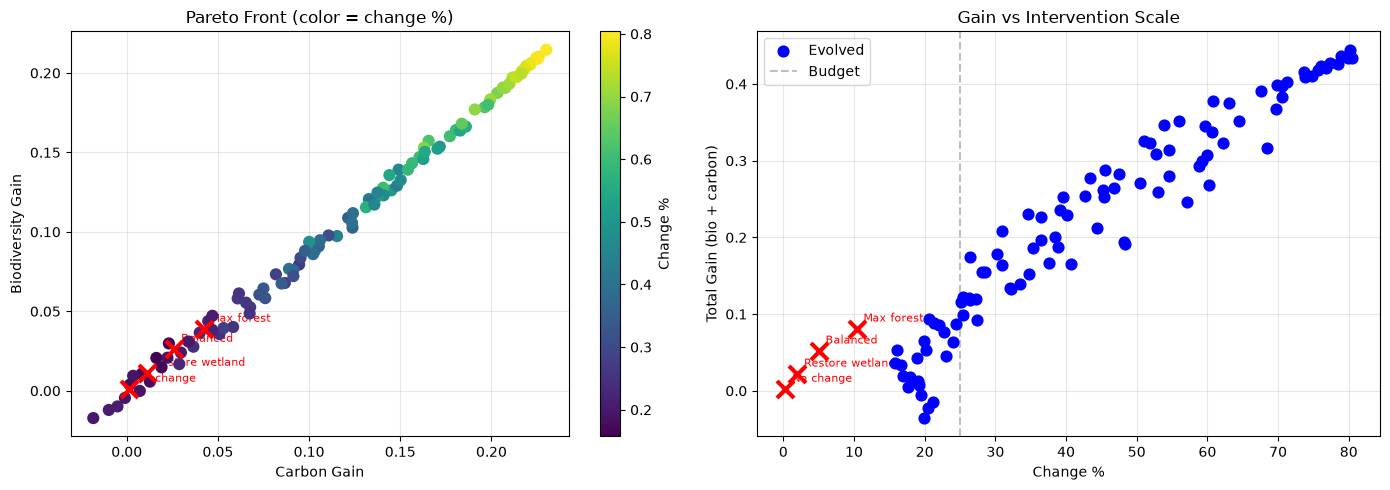

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biodiversity vs Carbon (color by change%)
sc = axes[0].scatter(pareto_df['carbon_gain'], pareto_df['biodiversity_gain'],
                     c=pareto_df['changed_pct'], cmap='viridis', s=60, zorder=5)
plt.colorbar(sc, ax=axes[0], label='Change %')
for _, row in baseline_df.iterrows():
    axes[0].scatter(row['carbon_gain'], row['biodiversity_gain'],
                   marker='x', s=150, c='red', linewidths=3, zorder=6)
    axes[0].annotate(row.name, (row['carbon_gain'], row['biodiversity_gain']),
                    textcoords='offset points', xytext=(5,5), fontsize=8, color='red')
axes[0].set_xlabel('Carbon Gain')
axes[0].set_ylabel('Biodiversity Gain')
axes[0].set_title('Pareto Front (color = change %)')
axes[0].grid(True, alpha=0.3)

# Gain vs Change%
pareto_df['total_gain'] = pareto_df['biodiversity_gain'] + pareto_df['carbon_gain']
axes[1].scatter(pareto_df['changed_pct']*100, pareto_df['total_gain'],
               c='blue', s=60, zorder=5, label='Evolved')
for _, row in baseline_df.iterrows():
    axes[1].scatter(row['changed_pct']*100, row['biodiversity_gain']+row['carbon_gain'],
                   marker='x', s=150, c='red', linewidths=3, zorder=6)
    axes[1].annotate(row.name, (row['changed_pct']*100, row['biodiversity_gain']+row['carbon_gain']),
                    textcoords='offset points', xytext=(5,5), fontsize=8, color='red')
axes[1].axvline(config['max_changed_pct']*100, color='gray', linestyle='--', alpha=0.5, label='Budget')
axes[1].set_xlabel('Change %')
axes[1].set_ylabel('Total Gain (bio + carbon)')
axes[1].set_title('Gain vs Intervention Scale')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Inspect Best Within-Budget Policy

Pick the policy with highest total gain that stays within the change budget.

In [7]:
budget = config['max_changed_pct']
within_budget = pareto_df[pareto_df['changed_pct'] <= budget]

if within_budget.empty:
    best_idx = (pareto_df['changed_pct'] - budget).abs().idxmin()
    print(f'No policy within {budget:.0%} budget. Showing closest:')
else:
    within_budget = within_budget.copy()
    within_budget['total_gain'] = within_budget['biodiversity_gain'] + within_budget['carbon_gain']
    best_idx = within_budget['total_gain'].idxmax()
    print(f'Best policy within {budget:.0%} budget:')

best = pareto_df.loc[best_idx]
print(f"  Biodiversity: {best['biodiversity_gain']:.4f}")
print(f"  Carbon: {best['carbon_gain']:.4f}")
print(f"  Cost: {best['cost']:.4f}")
print(f"  Changed: {best['changed_pct']:.1%}")

Best policy within 25% budget:
  Biodiversity: 0.0472
  Carbon: 0.0469
  Cost: 0.9081
  Changed: 20.6%


In [8]:
# Visualize what this policy changes
best_prescriptor = front0[int(best['id'])]
targets = best_prescriptor.prescribe(feat_norm)
current = np.column_stack([gdf['forest_pct'], gdf['wetland_pct'], gdf['agriculture_pct'], gdf['grassland_pct']])

# Net change per group
available = np.clip(1 - gdf['urban_pct'].values - gdf['water_pct'].values, 0, 1)
target_sum = targets.sum(axis=1, keepdims=True)
target_sum = np.where(target_sum > 0, target_sum, 1.0)
targets_scaled = targets / target_sum * available[:, None]
delta = targets_scaled - current

gdf['forest_delta'] = delta[:, 0]
gdf['wetland_delta'] = delta[:, 1]
gdf['agri_delta'] = delta[:, 2]
gdf['grass_delta'] = delta[:, 3]
gdf['total_change'] = np.abs(delta).sum(axis=1) / 2

print(f"Mean changes per group:")
print(f"  Forest:  {delta[:,0].mean():+.4f}")
print(f"  Wetland: {delta[:,1].mean():+.4f}")
print(f"  Agri:    {delta[:,2].mean():+.4f}")
print(f"  Grass:   {delta[:,3].mean():+.4f}")

Mean changes per group:
  Forest:  +0.0387
  Wetland: +0.0321
  Agri:    -0.0621
  Grass:   -0.0065


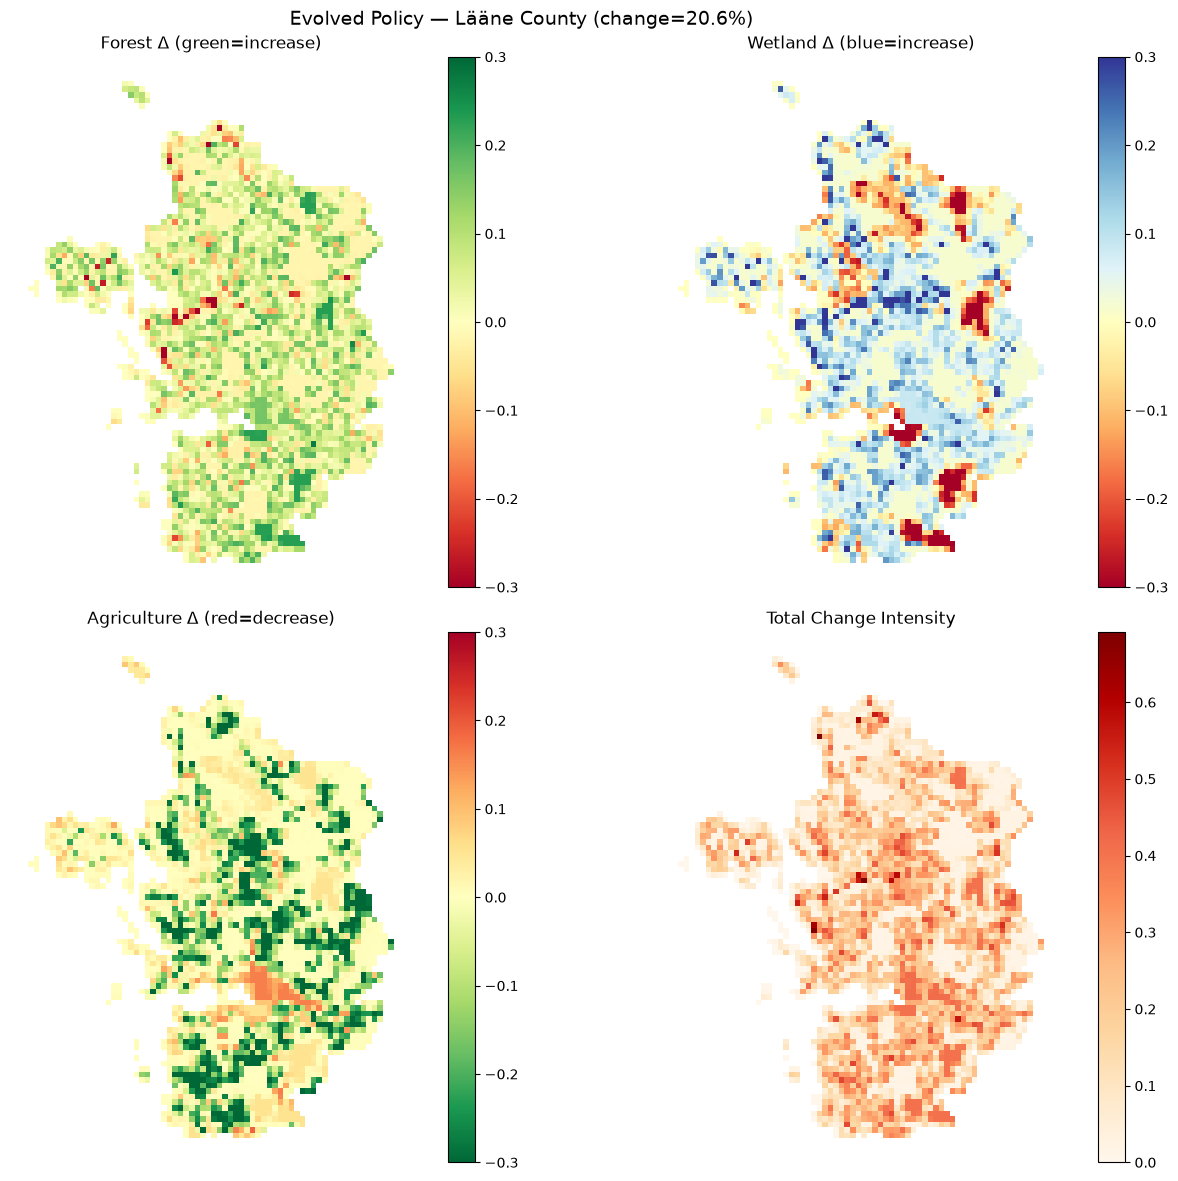

In [9]:
# Map the transitions
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

gdf.plot(column='forest_delta', legend=True, ax=axes[0,0], cmap='RdYlGn', vmin=-0.3, vmax=0.3)
axes[0,0].set_title('Forest Δ (green=increase)')

gdf.plot(column='wetland_delta', legend=True, ax=axes[0,1], cmap='RdYlBu', vmin=-0.3, vmax=0.3)
axes[0,1].set_title('Wetland Δ (blue=increase)')

gdf.plot(column='agri_delta', legend=True, ax=axes[1,0], cmap='RdYlGn_r', vmin=-0.3, vmax=0.3)
axes[1,0].set_title('Agriculture Δ (red=decrease)')

gdf.plot(column='total_change', legend=True, ax=axes[1,1], cmap='OrRd')
axes[1,1].set_title('Total Change Intensity')

for ax in axes.flat:
    ax.set_axis_off()
plt.suptitle(f'Evolved Policy — {COUNTY_NAME} County (change={best["changed_pct"]:.1%})', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Before vs After — Dominant Land Cover

Compare original and proposed dominant land cover per cell.
Each cell is colored by whichever land type has the highest fraction.

In [10]:
# Compute dominant land cover: original vs proposed
groups = ['forest', 'wetland', 'agriculture', 'grassland']
colors = {'forest': '#228B22', 'wetland': '#4682B4', 'agriculture': '#DAA520', 'grassland': '#9ACD32', 'water': '#87CEEB', 'urban': '#808080'}

# Original dominant (from current fractions)
current_cols = [f'{g}_pct' for g in groups] + ['water_pct', 'urban_pct']
all_groups = groups + ['water', 'urban']
current_vals = gdf[current_cols].values
gdf['dominant_original'] = [all_groups[i] for i in current_vals.argmax(axis=1)]

# Proposed dominant (from evolved targets)
available = np.clip(1 - gdf['urban_pct'].values - gdf['water_pct'].values, 0, 1)
target_sum = targets.sum(axis=1, keepdims=True)
target_sum = np.where(target_sum > 0, target_sum, 1.0)
targets_scaled = targets / target_sum * available[:, None]

# Build full proposed array including water and urban (unchanged)
proposed_vals = np.column_stack([targets_scaled, gdf['water_pct'].values, gdf['urban_pct'].values])
gdf['dominant_proposed'] = [all_groups[i] for i in proposed_vals.argmax(axis=1)]

# Where did dominant type change?
gdf['dominant_changed'] = gdf['dominant_original'] != gdf['dominant_proposed']
print(f"Cells with changed dominant type: {gdf['dominant_changed'].sum()} / {len(gdf)} ({gdf['dominant_changed'].mean():.1%})")

Cells with changed dominant type: 319 / 2806 (11.4%)


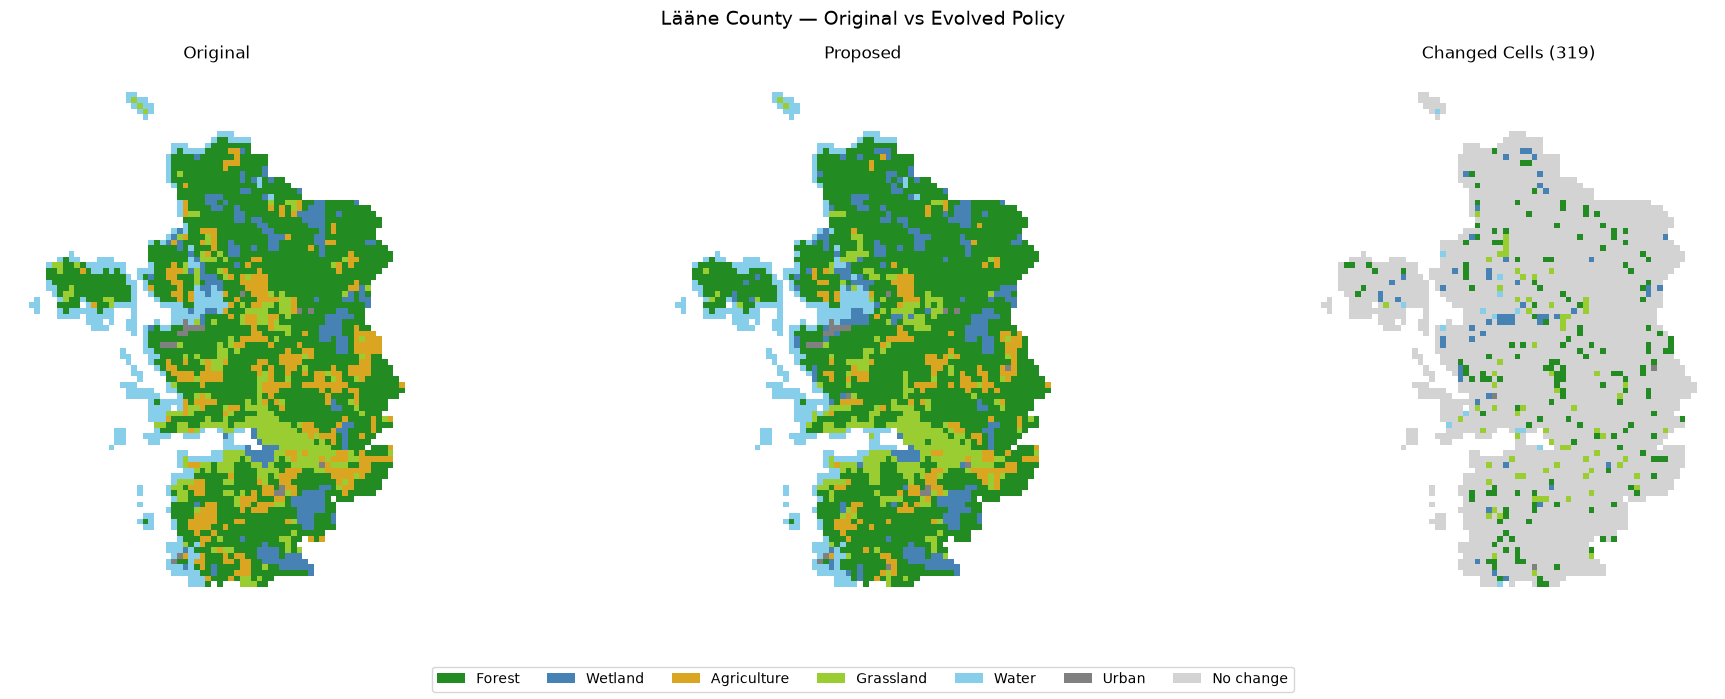

In [12]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Use same color for each group in ALL maps
def plot_dominant(ax, gdf, column, title):
    """Plot cells colored by dominant land cover, using consistent colors."""
    for group in all_groups:
        subset = gdf[gdf[column] == group]
        if not subset.empty:
            subset.plot(ax=ax, color=colors[group], edgecolor='none')
    ax.set_title(title)
    ax.set_axis_off()

plot_dominant(axes[0], gdf, 'dominant_original', 'Original')
plot_dominant(axes[1], gdf, 'dominant_proposed', 'Proposed')

# Third map: gray for unchanged, colored for changed cells
unchanged = gdf[~gdf['dominant_changed']]
changed = gdf[gdf['dominant_changed']]
if not unchanged.empty:
    unchanged.plot(ax=axes[2], color='#D3D3D3', edgecolor='none')
for group in all_groups:
    subset = changed[changed['dominant_proposed'] == group]
    if not subset.empty:
        subset.plot(ax=axes[2], color=colors[group], edgecolor='none')
axes[2].set_title(f'Changed Cells ({gdf["dominant_changed"].sum()})')
axes[2].set_axis_off()

# Shared legend
legend_patches = [Patch(facecolor=colors[g], label=g.capitalize()) for g in all_groups]
legend_patches.append(Patch(facecolor='#D3D3D3', label='No change'))
fig.legend(handles=legend_patches, loc='lower center', ncol=7, fontsize=10)

plt.suptitle(f'{COUNTY_NAME} County — Original vs Evolved Policy', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()